In [3]:
!pip install tensorflow tensorflow-model-optimization opencv-python

In [ ]:
import tensorflow as tf
import numpy as np
import os

IMG_SIZE = 96
BATCH_SIZE = 64

train_dir = "new_split_dataset/train"
test_dir = "new_split_dataset/test"


def load_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [96, 96])
    img = tf.cast(img, tf.float32) / 255.0
    label = parse_label(path)
    return img, label


def parse_label(path):
    filename = tf.strings.split(path, os.sep)[-1]

    is_cat = tf.strings.regex_full_match(filename, r"cat\..*")
    is_dog = tf.strings.regex_full_match(filename, r"dog\..*")

    return tf.where(is_cat, 0,
           tf.where(is_dog, 1, 2))

def build_dataset(folder):
    files = tf.data.Dataset.list_files(folder + "/*")
    ds = files.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_dir)
test_ds = build_dataset(test_dir)

# ----------------------------
# 📌 MODEL
# ----------------------------
def ds_block(x, filters, stride):
    x = tf.keras.layers.DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU(6.)(x)

    x = tf.keras.layers.Conv2D(filters, 1, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU(6.)(x)
    return x

inputs = tf.keras.Input(shape=(96, 96, 3))

x = tf.keras.layers.Conv2D(8, 3, strides=2, padding='same', use_bias=False)(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU(6.)(x)

x = ds_block(x, 16, 1)
x = ds_block(x, 24, 2)
x = ds_block(x, 32, 1)
x = ds_block(x, 48, 2)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ----------------------------
# 📌 TRAIN
# ----------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

model.fit(train_ds, validation_data=test_ds, epochs=30, callbacks=callbacks)

# ----------------------------
# 📌 SAVE FP32
# ----------------------------
model.save("new_models/model_fp32.h5")

# ----------------------------
# 📊 TEST FP32
# ----------------------------
loss, acc = model.evaluate(test_ds)
print("FP32 accuracy:", acc)

# ----------------------------
# 📌 TFLITE FP32
# ----------------------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_fp32 = converter.convert()

with open("new_models/model_fp32.tflite", "wb") as f:
    f.write(tflite_fp32)




Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 8)      │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 48, 48, 8)      │            72 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 16)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 24, 24, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 24)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 24, 24, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 24, 24, 24)     │           216 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 24, 24, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │           768 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,731 (18.48 KB)

 Trainable params: 4,315 (16.86 KB)

 Non-trainable params: 416 (1.62 KB)

...

INFO:tensorflow:Assets written to: /var/folders/yy/bkblty8d71331h4hbflvc5nc0000gn/T/tmp48xej97x/assets


Saved artifact at '/var/folders/yy/bkblty8d71331h4hbflvc5nc0000gn/T/tmp48xej97x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  13345889440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13345802544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13345803952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13345802720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13345801664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13345799328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13345799152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4610164512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13345797920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13345798976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4610163984: T

/Users/dilaraorazmetova/anaconda3/envs/jupyter-env/lib/python3.9/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1773842859.779533 4280889 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773842859.779557 4280889 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-18 17:07:39.779714: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/yy/bkblty8d71331h4hbflvc5nc0000gn/T/tmp48xej97x
2026-03-18 17:07:39.781382: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-18 17:07:39.781388: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/yy/bkblty8d71331h4hbflvc5nc0000gn/T/tmp48xej97x
2026-03-18 17:07:39.798785: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-18 17:07:39.8

INT8 size KB: 16.9453125


AttributeError: EagerTensor object has no attribute 'astype'. 
        If you are looking for numpy-related methods, please run the following:
        tf.experimental.numpy.experimental_enable_numpy_behavior()
      

In [ ]:

# ----------------------------
# 📊 TEST TFLITE FP32
# ----------------------------
def evaluate_tflite(model_bytes, dataset, int8=False):
    interpreter = tf.lite.Interpreter(model_content=model_bytes)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    correct = 0
    total = 0

    for images, labels in dataset:
        for i in range(images.shape[0]):
            input_data = images[i:i+1]

            if int8:
                scale, zero = input_details[0]['quantization']

                input_data = input_data.numpy()
                input_data = input_data / scale + zero
                input_data = np.round(input_data).astype(np.int8)

            else:
                input_data = input_data.numpy().astype(np.float32)

            interpreter.set_tensor(input_details[0]['index'], input_data)
            interpreter.invoke()

            output = interpreter.get_tensor(output_details[0]['index'])

            if int8:
                scale, zero = output_details[0]['quantization']
                output = scale * (output.astype(np.float32) - zero)

            pred = np.argmax(output)

            if pred == labels[i].numpy():
                correct += 1
            total += 1

    return correct / total

In [4]:

# ----------------------------
# 📊 TEST INT8
# ----------------------------
acc_int8 = evaluate_tflite(tflite_int8, test_ds, int8=True)
print("INT8 accuracy:", acc_int8)

INT8 accuracy: 0.82144


2026-03-19 12:31:03.822256: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/dilaraorazmetova/anaconda3/envs/jupyter-env/lib/python3.9/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2026-03-19 12:31:15.582099: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Model  Accuracy  Precision    Recall  F1-score
0  FP32  0.822827   0.822446  0.822827  0.822323
1  INT8  0.821440   0.820209  0.821440  0.820741


<Figure size 640x480 with 0 Axes>

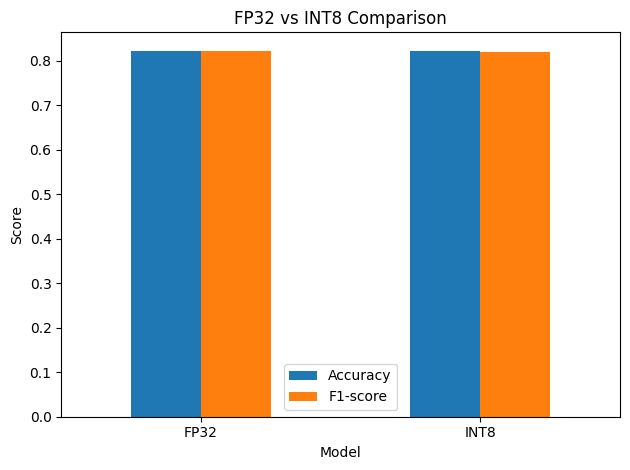

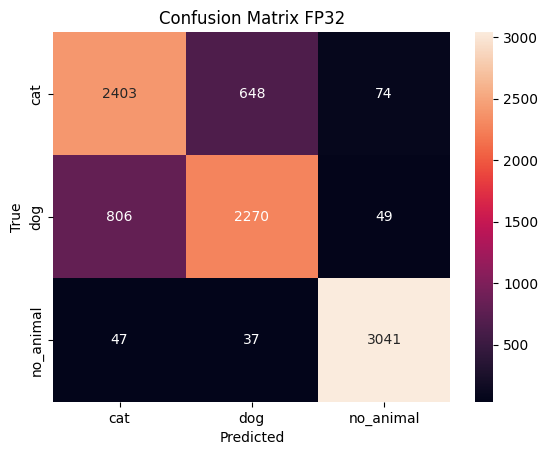

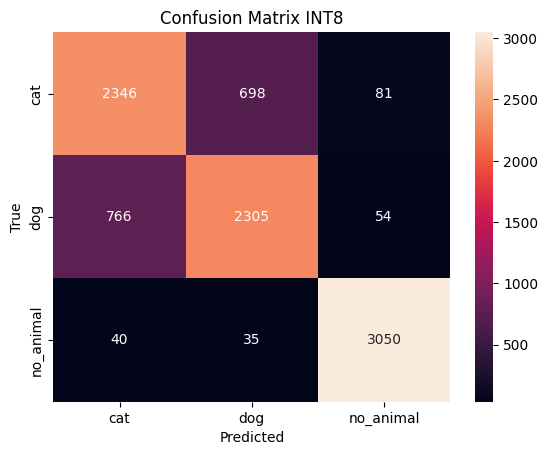

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import os
IMG_SIZE = 96
BATCH_SIZE = 64
EPOCHS = 30

train_dir = "new_split_dataset/train"
test_dir = "new_split_dataset/test"
def parse_label(path):
    filename = tf.strings.split(path, os.sep)[-1]

    is_cat = tf.strings.regex_full_match(filename, r"cat\..*")
    is_dog = tf.strings.regex_full_match(filename, r"dog\..*")

    return tf.where(is_cat, 0,
           tf.where(is_dog, 1, 2))  # 2 = no_animal

# =========================
# 📌 ЗАГРУЗКА ДАТАСЕТА
# =========================
# используем твой test_ds
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    label = parse_label(path)
    return img, label

def augment(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    return img

def build_dataset(folder, training=False):
    files = tf.data.Dataset.list_files(folder + "/*.jpg")

    ds = files.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (augment(x), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2000)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_dir, training=True)
test_ds = build_dataset(test_dir, training=False)
# =========================
# 📌 PREDICTION (Keras)
# =========================
def predict_keras(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

    return np.array(y_true), np.array(y_pred)

# =========================
# 📌 PREDICTION (TFLITE)
# =========================
def predict_tflite(model_bytes, dataset, int8=False):
    interpreter = tf.lite.Interpreter(model_content=model_bytes)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    y_true = []
    y_pred = []

    for images, labels in dataset:
        for i in range(images.shape[0]):
            input_data = images[i:i+1]

            if int8:
                scale, zero = input_details[0]['quantization']
                input_data = input_data.numpy()
                input_data = input_data / scale + zero
                input_data = np.round(input_data).astype(np.int8)
            else:
                input_data = input_data.numpy().astype(np.float32)

            interpreter.set_tensor(input_details[0]['index'], input_data)
            interpreter.invoke()

            output = interpreter.get_tensor(output_details[0]['index'])

            if int8:
                scale, zero = output_details[0]['quantization']
                output = scale * (output.astype(np.float32) - zero)

            pred = np.argmax(output)

            y_pred.append(pred)
            y_true.append(labels[i].numpy())

    return np.array(y_true), np.array(y_pred)

# =========================
# 📌 ЗАГРУЗКА МОДЕЛЕЙ
# =========================
keras_model = tf.keras.models.load_model("new_models/model_fp32.h5")

tflite_fp32 = open("new_models/model_fp32.tflite", "rb").read()
tflite_int8 = open("new_models/model_int8.tflite", "rb").read()

# =========================
# 📊 ПРЕДСКАЗАНИЯ
# =========================
y_true_fp32, y_pred_fp32 = predict_keras(keras_model, test_ds)
y_true_int8, y_pred_int8 = predict_tflite(tflite_int8, test_ds, int8=True)

# =========================
# 📊 METRICS
# =========================
report_fp32 = classification_report(y_true_fp32, y_pred_fp32, output_dict=True)
report_int8 = classification_report(y_true_int8, y_pred_int8, output_dict=True)

acc_fp32 = report_fp32["accuracy"]
acc_int8 = report_int8["accuracy"]

# =========================
# 📊 TABLE
# =========================
df = pd.DataFrame({
    "Model": ["FP32", "INT8"],
    "Accuracy": [acc_fp32, acc_int8],
    "Precision": [report_fp32["weighted avg"]["precision"],
                  report_int8["weighted avg"]["precision"]],
    "Recall": [report_fp32["weighted avg"]["recall"],
               report_int8["weighted avg"]["recall"]],
    "F1-score": [report_fp32["weighted avg"]["f1-score"],
                 report_int8["weighted avg"]["f1-score"]],
})

print(df)

# =========================
# 📊 BAR CHART
# =========================
plt.figure()
df.set_index("Model")[["Accuracy", "F1-score"]].plot(kind="bar")
plt.title("FP32 vs INT8 Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================
# 📊 CONFUSION MATRIX
# =========================
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=["cat", "dog", "no_animal"],
                yticklabels=["cat", "dog", "no_animal"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_cm(y_true_fp32, y_pred_fp32, "Confusion Matrix FP32")
plot_cm(y_true_int8, y_pred_int8, "Confusion Matrix INT8")